In [2]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
from statistics import median
from prettytable import PrettyTable
import ultralytics
from ultralytics import YOLO

# Dataset completo

O dataset contém 13.427 imagens capturadas por câmera com resolução de 1280 × 720 pixels e cerca de 24.000 semáforos anotados. As anotações incluem as caixas delimitadoras (bounding boxes) dos semáforos, bem como o estado atual (luz ativa) de cada semáforo.

# Conjunto de treinamento (Training set original)

- 5093 imagens
- Anotadas aproximadamente a cada 2 segundos
- 10.756 semáforos anotados
- Largura mediana dos semáforos: aproximadamente 8,6 pixels
- 15 classes diferentes
- 170 semáforos estão parcialmente ocluídos

# Conjunto de teste (Test set original)

- 8334 imagens consecutivas
- Anotadas a aproximadamente 15 quadros por segundo (15 FPS)
- 13.486 semáforos anotados
- Largura mediana dos semáforos: 8,5 pixels
- 4 classes (vermelho, amarelo, verde e apagado)
- 2088 semáforos estão parcialmente ocluídos

Observação1: Agrupamos as 15 classes de treino e as 4 de teste em apenas 3( Red, Green, Yellow). Razão: Como pegamos poucas imagens a quantidade de exemplos de apagado e outras classes é muito pequeno.

Observação2: Nós usamos as imagens do conjunto de treino tanto para treino, teste e validação pela maior variedade de imagens. Razão: como as imagens de teste foram capturadas em 15 FPS muitos exemplos vazios. No dataset de treino temos aproximadamente 2,11 semáforos anotados por imagem, no de teste apenas 1,61. Além disso quantidade muito maior de semáforos parcialmente ocluídos no de teste.

Observação3: Usamos as imagens no formato rgb.

# Imagens sem semáforos

In [14]:
path = Path ("labels")
extensoes= ["train","val","test"]
contador_vazios=0
for pasta in extensoes:
    caminho= path / pasta
    for arquivo in caminho.iterdir():
        if arquivo.is_file():
            if os.path.getsize(arquivo) == 0:
                    contador_vazios+=1
print(f'Quantidade de imagens sem presença de semáforos na amostra:{contador_vazios}')

Quantidade de imagens sem presença de semáforos na amostra:623


# Total de boxes por cor

In [15]:
path = Path ("labels")
extensoes= ["train","val","test"]
contador = {
    "red": 0,
    "yellow": 0,
    "green": 0,
}
for pasta in extensoes:
    caminho= path / pasta
    for arquivo in caminho.iterdir():
        if arquivo.is_file():
            with open(arquivo, "r") as f:
                for linha in f:
                    linha = linha.strip()
                    tipo = int(linha.split()[0])
                    match tipo:
                        case 0:
                            contador["red"]+=1
                        case 1:
                            contador["yellow"]+=1
                        case 2:
                            contador["green"]+=1

tabela = PrettyTable()

tabela.field_names = ["Cor", "Quantidade de boxes"]

tabela.add_row(["Red", contador["red"]])
tabela.add_row(["Yellow", contador["yellow"]])
tabela.add_row(["Green", contador["green"]])

print(tabela)

+--------+---------------------+
|  Cor   | Quantidade de boxes |
+--------+---------------------+
|  Red   |         1100        |
| Yellow |         143         |
| Green  |         1439        |
+--------+---------------------+


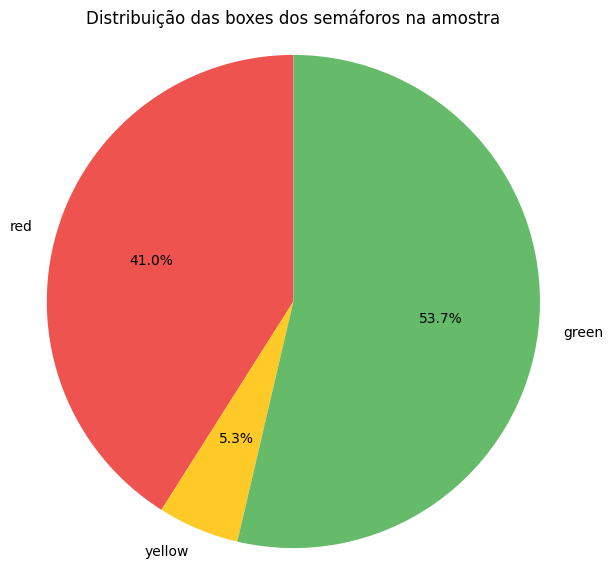

In [16]:
#Gráfico de pizza mostrando número de cores de semáforos anotados na amostra
labels = list(contador.keys())
valores = list(contador.values())

plt.figure(figsize=(7, 7))
plt.pie(
    valores,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors = ["#EF5350","#FFCA28","#66BB6A"]   
)

plt.title("Distribuição das boxes dos semáforos na amostra")
plt.axis("equal")  
plt.show()

# Semáforos por imagem

In [17]:
semaforos=[]
for pasta in extensoes:
    caminho= path / pasta
    for arquivo in caminho.iterdir():
        if arquivo.is_file():
            if os.path.getsize(arquivo) != 0:
                with open(arquivo, "r") as f:
                    semaforo=0
                    for linha in f:
                        semaforo+=1
                    semaforos.append(semaforo)
print(f'Média de semáforos em imagens com pelo menos 1 semáforo: {sum(semaforos)/len(semaforos):.2f}')
print(f'Média de semáforos em todas as imagens: {sum(semaforos)/(len(semaforos)+contador_vazios):.2f}')
print(f'Maior número de semáforos em uma imagem: {max(semaforos)}')

Média de semáforos em imagens com pelo menos 1 semáforo: 3.24
Média de semáforos em todas as imagens: 1.85
Maior número de semáforos em uma imagem: 10


# Tamanho das bounding boxes

In [18]:
areas=[]
larguras=[]
alturas=[]
for pasta in extensoes:
    caminho= path / pasta
    for arquivo in caminho.iterdir():
        if arquivo.is_file():
            with open(arquivo, "r") as f:
                for linha in f:
                    linha = linha.strip()
                    largura = float(linha.split()[3])
                    altura = float(linha.split()[4])
                    largura_pixel= largura *1280
                    altura_pixel = altura*720
                    larguras.append(largura_pixel)
                    alturas.append(altura_pixel)
                    areas.append(altura_pixel*largura_pixel)
                    
tabela = PrettyTable()

tabela.field_names = ["Métrica", "Valor"]

tabela.add_row(["Largura mediana (px)", f"{median(larguras):.2f}"])
tabela.add_row(["Largura média (px)", f"{sum(larguras)/len(larguras):.2f}"])
tabela.add_row(["Altura mediana (px)", f"{median(alturas):.2f}"])
tabela.add_row(["Altura média (px)", f"{sum(alturas)/len(alturas):.2f}"])
tabela.add_row(["Área média (px²)", f"{sum(areas)/len(areas):.2f}"])

print(tabela)


+----------------------+--------+
|       Métrica        | Valor  |
+----------------------+--------+
| Largura mediana (px) |  8.39  |
|  Largura média (px)  | 11.08  |
| Altura mediana (px)  | 18.66  |
|  Altura média (px)   | 24.20  |
|   Área média (px²)   | 391.35 |
+----------------------+--------+


Observação: o gráfico abaixo e a tabela acima fazem sentido sabendo que semáforos em sua maioria são retângulos verticais, ou seja, altura>largura

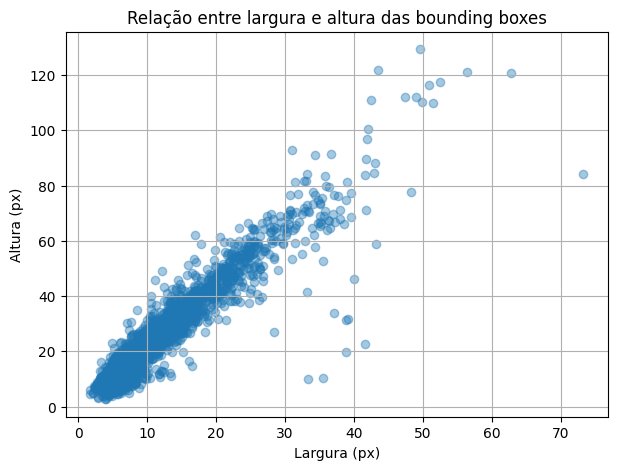

In [19]:
plt.figure(figsize=(7, 5))

plt.scatter(larguras, alturas, alpha=0.4)

plt.xlabel("Largura (px)")
plt.ylabel("Altura (px)")
plt.title("Relação entre largura e altura das bounding boxes")

plt.grid(True)
plt.show()

# Localização dos semáforos

Observação: O eixo y está invertido porque em YOLO 0 é o topo e 1.0 é o fundo

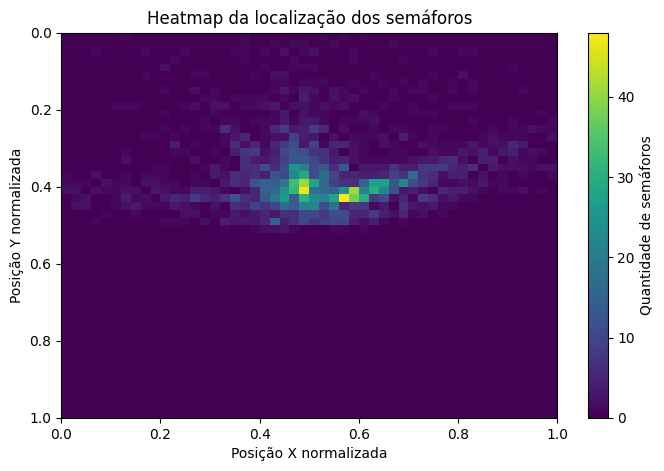

In [20]:
xs = []
ys = []

for pasta in extensoes:
    caminho = path / pasta

    for arquivo in caminho.iterdir():
        if arquivo.is_file():
            with open(arquivo, "r") as f:
                for linha in f:
                    linha = linha.strip()

                    if not linha:
                        continue

                    x = float(linha.split()[1])
                    y = float(linha.split()[2])

                    xs.append(x)
                    ys.append(y)

plt.figure(figsize=(8, 5))

plt.hist2d(xs, ys, bins=50, range=[[0, 1], [0, 1]])
plt.colorbar(label="Quantidade de semáforos")

plt.xlabel("Posição X normalizada")
plt.ylabel("Posição Y normalizada")
plt.title("Heatmap da localização dos semáforos")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.gca().invert_yaxis()

plt.show()

In [21]:
#Essa tabela pode ir junto com o heatmap no slide
tabela = PrettyTable()

tabela.field_names = ["Métrica", "Mínimo", "Máximo"]

tabela.add_row([
    "Y (altura)",
    f"{min(ys):.4f}",
    f"{max(ys):.4f}"
])

tabela.add_row([
    "X (largura)",
    f"{min(xs):.4f}",
    f"{max(xs):.4f}"
])

print(tabela)

+-------------+--------+--------+
|   Métrica   | Mínimo | Máximo |
+-------------+--------+--------+
|  Y (altura) | 0.0070 | 0.5072 |
| X (largura) | 0.0041 | 0.9952 |
+-------------+--------+--------+


# Informações de Treino

Observação: 

            Acessando /runs/detect/train-8/results.png é possível obter os gráficos de treino do Yolo26small 

            Acessando /runs/detect/treino_nano/results.png é possível obter os gráfico de treino do Yolo26nano

Pode ser legal comparar ambos

In [25]:
#Não precisa dos infos pro slide só a tabela
models = YOLO("runs/detect/train-8/weights/best.pt")

models.info()

YOLO26s summary: 260 layers, 9,950,186 parameters, 0 gradients, 22.5 GFLOPs


(260, 9950186, 0, 22.5073152)

In [23]:
modeln = YOLO("runs/detect/treino_nano/weights/best.pt")

modeln.info()

YOLO26n summary: 260 layers, 2,504,970 parameters, 0 gradients, 5.8 GFLOPs


(260, 2504970, 0, 5.776076799999999)

In [24]:
tabela = PrettyTable()

tabela.field_names = ["Modelo", "Épocas", "Tempo de treino(s)","Parâmetros","FLOPS"]

tabela.add_row([
    "Yolo26 nano",
    "76",
    "493.93",
    "2,504,970",
    "5.8 GFLOPs"   
])

tabela.add_row([
    "Yolo26 small",
    "100",
    "1207.83",
    "9,950,186",
    "22.5 GFLOPs"   
])
print(tabela)

+--------------+--------+--------------------+------------+-------------+
|    Modelo    | Épocas | Tempo de treino(s) | Parâmetros |    FLOPS    |
+--------------+--------+--------------------+------------+-------------+
| Yolo26 nano  |   76   |       493.93       | 2,504,970  |  5.8 GFLOPs |
| Yolo26 small |  100   |      1207.83       | 9,950,186  | 22.5 GFLOPs |
+--------------+--------+--------------------+------------+-------------+
